# HW2: Word2Vector
## Start

In [8]:
%run define.ipynb
# start word2vec train process from here
txt_path = "data/"
save_vec_path = "model/word2vec/"
save_model_path = "model/"
zh_stop_path = "data/hit_stopwords.txt"
train_path = "data/train/"

D:\workdata\software\TEMP\USERTEMP\ipykernel_20364\1346027983.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  zh_train_data = torch.load(train_path+"zh_train_data.pth")

([3009, 3010, 3011, 3012, 3013, 3003, 3004, 3005, 3006, 3007], 3008)
CBOW(
  (embedding): Embedding(12598, 200)
  (fc1): Linear(in_features=200, out_features=12598, bias=True)
) SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
) CrossEntropyLoss()
Start zh training...


100%|██████████| 394/394 [00:01<00:00, 343.83it/s]


epoch 0, loss: 0.2960834844854092


100%|██████████| 394/394 [00:00<00:00, 705.43it/s]


...

epoch 7, loss: 0.29471474001435655


100%|██████████| 394/394 [00:00<00:00, 679.83it/s]


epoch 8, loss: 0.29451925738637397


100%|██████████| 394/394 [00:00<00:00, 696.65it/s]


epoch 9, loss: 0.29432379195604547
Training finished


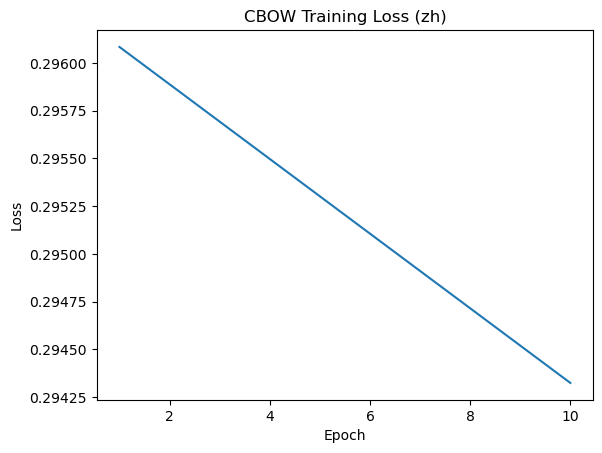

In [9]:
# load text
zh_text = load_data(txt_path, version='zh')
# create words
zh_words = preprocess_text(zh_text, zh_stop_path=zh_stop_path, language='zh')
# create vocab
zh_vocab = build_vocab(zh_words)
# create training data
zh_train_data = create_training_data(zh_words, zh_vocab, window_size=5)
random.shuffle(zh_train_data)
torch.save(zh_train_data, train_path+"zh_train_data.pth")
# load training data
zh_train_data = torch.load(train_path+"zh_train_data.pth")
print(zh_train_data[0])
# train zh model
model_zh = CBOW(vocab_size=len(zh_vocab), embedding_size=100).to(device)
# optimizer & loss function
optimizer, criterion = get_optim_and_loss(model_zh, "SGD", "cross")
print(model_zh, optimizer, criterion)
epochs = 1000
# set train mode
model_zh.train()
# start train
lossv_zh = []
print('Start zh training...')
train(model_zh, zh_train_data, optimizer, criterion, epochs, lossv_zh, batch_size=32)
# plot 
plt.plot([epoch+1 for epoch in range(0, epochs)], lossv_zh)
plt.title('CBOW Training Loss (zh)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [10]:
# save
save_model(model_zh, save_model_path, version='zh')
save_word_vectors(model_zh, zh_vocab, save_vec_path, version='zh')

## 7. An Example Task to Use Trained Word Vectors
### Compute similarity among words

In [20]:
# load word vectors
word_vectors_zh = load_word_vectors(save_vec_path+"zh")

top_n = 5
zh_word = "人民"
# chinese
top_similarities_zh = find_similar_words(zh_word, word_vectors_zh, top_n)
print(f"Most similar top {top_n} words to '{zh_word}':")
for word, similarity in top_similarities_zh:
    print(f"{word}: {similarity:.3f}")

Most similar top 5 words to '人民':
李诗佳: 1.349
交通: 1.271
亿: 1.253
讼诉: 1.235
停伐: 1.230
